In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
df = pd.read_csv("creditcard_2023.csv")
df.head()


,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0.0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0.0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0.0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0.0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0.0


In [ ]:
df['id'].count()

np.int64(5523)

In [ ]:
df.info()
df.describe()
df['Class'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5523 entries, 0 to 5522
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      5523 non-null   int64  
 1   V1      5523 non-null   float64
 2   V2      5523 non-null   float64
 3   V3      5523 non-null   float64
 4   V4      5523 non-null   float64
 5   V5      5523 non-null   float64
 6   V6      5523 non-null   float64
 7   V7      5523 non-null   float64
 8   V8      5523 non-null   float64
 9   V9      5523 non-null   float64
 10  V10     5523 non-null   float64
 11  V11     5522 non-null   float64
 12  V12     5522 non-null   float64
 13  V13     5522 non-null   float64
 14  V14     5522 non-null   float64
 15  V15     5522 non-null   float64
 16  V16     5522 non-null   float64
 17  V17     5522 non-null   float64
 18  V18     5522 non-null   float64
 19  V19     5522 non-null   float64
 20  V20     5522 non-null   float64
 21  V21     5522 non-null   float64
 22  

,count
Class,
0.0,5519
1.0,3


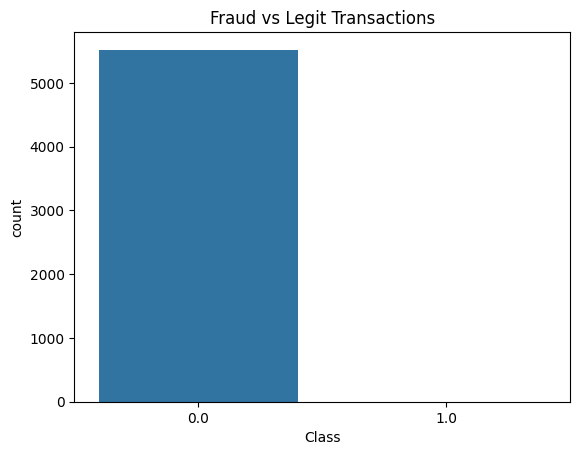

In [ ]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Legit Transactions")
plt.show()


In [ ]:
corr_matrix=df.corr()

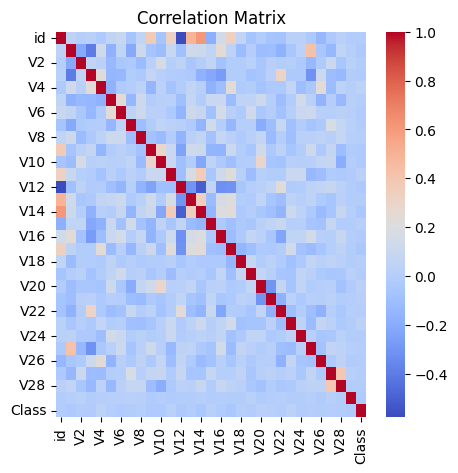

In [ ]:
plt.figure(figsize=(5,5))
sns.heatmap(corr_matrix,cmap='coolwarm',annot=False)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# ❗ Remove unnecessary columns (like id)
df = df.drop(columns=['id'], errors='ignore')

In [ ]:
# Split features & target
X = df.drop('Class', axis=1)
y = df['Class']


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# ✅ Combine ONLY training data for balancing
train_df = pd.concat([X_train, y_train], axis=1)

fraud = train_df[train_df['Class'] == 1]
legit = train_df[train_df['Class'] == 0].sample(len(fraud), random_state=42)

balanced_df = pd.concat([fraud, legit])

X_train_bal = balanced_df.drop('Class', axis=1)
y_train_bal = balanced_df['Class']


In [ ]:
# ✅ HANDLE NaN VALUES (CRITICAL FIX)
imputer = SimpleImputer(strategy='mean')

X_train_bal = imputer.fit_transform(X_train_bal)
X_test = imputer.transform(X_test)

In [ ]:
# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_bal, y_train_bal)

LogisticRegression(max_iter=1000)

In [ ]:
# Predict
y_pred = model.predict(X_test)

In [ ]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8135746606334842
Precision: 0.004830917874396135
Recall: 1.0
F1 Score: 0.009615384615384616

Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      0.81      0.90      1104
         1.0       0.00      1.00      0.01         1

    accuracy                           0.81      1105
   macro avg       0.50      0.91      0.45      1105
weighted avg       1.00      0.81      0.90      1105



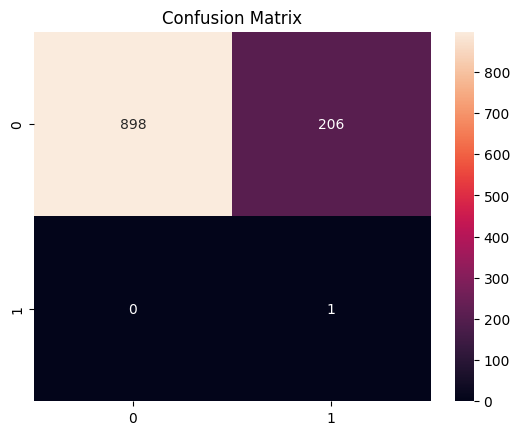

In [ ]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 66.4 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

# ---------------------- UI ----------------------
st.set_page_config(page_title="Fraud Detection", layout="wide")
st.title("💳 Credit Card Fraud Detection")
st.write("Upload a CSV file of transactions to detect fraudulent activity.")

# ---------------------- Load & Train ----------------------
@st.cache_resource
def load_and_train():
    df = pd.read_csv("creditcard_2023.csv")
    df = df.drop(columns=['id'], errors='ignore')

    X = df.drop('Class', axis=1)
    y = df['Class']

    imputer = SimpleImputer(strategy='mean')
    X_imp = imputer.fit_transform(X)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_imp, y)

    feature_cols = X.columns.tolist()
    return model, imputer, feature_cols

try:
    model, imputer, feature_cols = load_and_train()
    st.success("Model ready ✅")
except Exception as e:
    st.error("❌ Failed to load/train model. Ensure creditcard_2023.csv is uploaded.")
    st.stop()

# ---------------------- File Upload ----------------------
uploaded_file = st.file_uploader("📂 Upload CSV (with same feature columns)", type=["csv"])

if uploaded_file is not None:
    try:
        input_df = pd.read_csv(uploaded_file)
        st.subheader("📊 Uploaded Data Preview")
        st.dataframe(input_df.head())

        # Drop non-feature columns if present
        input_df = input_df.drop(columns=['Class'], errors='ignore')
        input_df = input_df.drop(columns=['id'], errors='ignore')

        # Ensure same columns/order as training data
        missing_cols = [c for c in feature_cols if c not in input_df.columns]
        extra_cols = [c for c in input_df.columns if c not in feature_cols]

        # Add missing columns as 0
        for c in missing_cols:
            input_df[c] = 0.0

        # Remove extra columns
        if extra_cols:
            input_df = input_df.drop(columns=extra_cols)

        # Reorder columns to match training
        input_df = input_df[feature_cols]

        # Impute
        X_user = imputer.transform(input_df)

        # Predict
        preds = model.predict(X_user)
        probs = model.predict_proba(X_user)[:, 1]

        # Attach results
        result_df = input_df.copy()
        result_df["Fraud_Probability"] = probs
        result_df["Prediction"] = preds  # 1 = Fraud, 0 = Legit

        st.subheader("🔍 Prediction Results")
        st.dataframe(result_df)

        # Summary
        fraud_count = int((preds == 1).sum())
        total = len(preds)

        st.markdown(f"### 🚨 Fraud Transactions: {fraud_count} / {total}")

        # Optional metrics if true labels provided
        if "Class" in pd.read_csv(uploaded_file).columns:
            y_true = pd.read_csv(uploaded_file)["Class"].values
            st.subheader("📈 Evaluation (from uploaded labels)")
            st.write("Precision:", precision_score(y_true, preds))
            st.write("Recall:", recall_score(y_true, preds))
            st.write("F1 Score:", f1_score(y_true, preds))

        # Download results
        csv = result_df.to_csv(index=False).encode('utf-8')
        st.download_button(
            label="⬇️ Download Results",
            data=csv,
            file_name="fraud_predictions.csv",
            mime="text/csv"
        )

    except Exception as e:
        st.error(f"❌ Error processing file: {e}")

# ---------------------- Single Row Quick Test ----------------------
st.divider()
st.subheader("⚡ Quick Test (Single Transaction)")

with st.expander("Enter a single transaction (auto-fills missing features with 0)"):
    user_vals = {}
    for col in feature_cols[:10]:  # keep UI light
        user_vals[col] = st.number_input(f"{col}", value=0.0)

    if st.button("Predict Single"):
        # Build full feature vector
        row = {c: 0.0 for c in feature_cols}
        row.update(user_vals)
        row_df = pd.DataFrame([row])

        X_row = imputer.transform(row_df)
        pred = model.predict(X_row)[0]
        prob = model.predict_proba(X_row)[0][1]

        if pred == 1:
            st.error(f"🚨 Fraud (prob={prob:.4f})")
        else:
            st.success(f"✅ Legit (prob={prob:.4f})")

Writing app.py


In [ ]:
from pyngrok import ngrok

# Kill previous tunnels (important)
ngrok.kill()

from pyngrok import ngrok

ngrok.set_auth_token("3CZi2x1Bjke92u85wNp9xO5y4Ms_57AzKZMxBenrqjRdfYtvp")


# Create tunnel
public_url = ngrok.connect(8501)
print("Your app URL:", public_url)



Your app URL: NgrokTunnel: "https://denote-unfocused-overhang.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!streamlit run app.py &




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.105.10.10:8501

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
  Stopping...
